QUESTION 1: Student Performance

In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(42)
df=pd.DataFrame({"student_id":range(1,501),
                 "study_hours":np.random.randint(1,10,500),
                 "attendance":np.random.randint(50,100,500),
                 "exam_score":np.random.randint(30,100,500)})

In [4]:
# Basic inspection
df.head()

,student_id,study_hours,attendance,exam_score
0,1,7,80,37
1,2,4,68,34
2,3,8,93,58
3,4,5,88,76
4,5,7,76,97


In [5]:
df.tail()

,student_id,study_hours,attendance,exam_score
495,496,7,85,85
496,497,9,94,50
497,498,4,73,76
498,499,4,64,88
499,500,6,78,35


In [7]:
df.sample(5)

,student_id,study_hours,attendance,exam_score
161,162,6,97,67
382,383,6,62,71
345,346,3,80,40
297,298,7,62,95
52,53,6,72,38


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   student_id   500 non-null    int64
 1   study_hours  500 non-null    int64
 2   attendance   500 non-null    int64
 3   exam_score   500 non-null    int64
dtypes: int64(4)
memory usage: 15.8 KB


In [9]:
# Feature engineering
df["performance"]=pd.cut(df["exam_score"],bins=[0,50,75,100],labels=["low","medium","high"])

In [10]:
df.sample(5)

,student_id,study_hours,attendance,exam_score,performance
189,190,3,78,86,high
299,300,2,74,71,medium
342,343,8,86,85,high
152,153,3,52,98,high
9,10,4,52,65,medium


In [11]:
# Statistical analysis
df.describe()

,student_id,study_hours,attendance,exam_score
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,4.906000,73.926000,64.308000
std,144.481833,2.612051,14.456227,19.808733
min,1.000000,1.000000,50.000000,30.000000
25%,125.750000,3.000000,61.000000,47.000000
50%,250.500000,5.000000,75.000000,65.000000
75%,375.250000,7.000000,86.000000,82.000000
max,500.000000,9.000000,99.000000,99.000000


In [12]:
df[["study_hours","attendance","exam_score"]].mean()

,0
study_hours,4.906
attendance,73.926
exam_score,64.308


In [13]:
# Group analysis
df.groupby("performance")["exam_score"].agg(["mean","min","max","count"])

/tmp/ipykernel_483/1885246460.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("performance")["exam_score"].agg(["mean","min","max","count"])


,mean,min,max,count
performance,,,,
low,39.958904,30,50,146
medium,62.881720,51,75,186
high,87.047619,76,99,168


In [19]:
# Filtering
high_performers=df[(df["study_hours"]>6)& (df["attendance"]>80)]
high_performers.count()

,0
student_id,66
study_hours,66
attendance,66
exam_score,66
performance,66


In [22]:
# Sorting
df.sort_values("exam_score",ascending=False).head(10)

,student_id,study_hours,attendance,exam_score,performance
447,448,1,89,99,high
340,341,3,80,99,high
393,394,7,51,99,high
179,180,2,76,99,high
255,256,3,85,99,high
72,73,9,90,99,high
152,153,3,52,98,high
13,14,6,77,98,high
398,399,2,50,98,high
221,222,8,78,98,high


In [23]:
# Correlation
df.corr(numeric_only=True)


,student_id,study_hours,attendance,exam_score
student_id,1.000000,-0.047810,-0.017097,0.028112
study_hours,-0.047810,1.000000,0.046094,-0.005830
attendance,-0.017097,0.046094,1.000000,-0.042155
exam_score,0.028112,-0.005830,-0.042155,1.000000


In [25]:
# Visualization (Matplotlib + Seaborn)
import matplotlib.pyplot as plt
import seaborn as sns

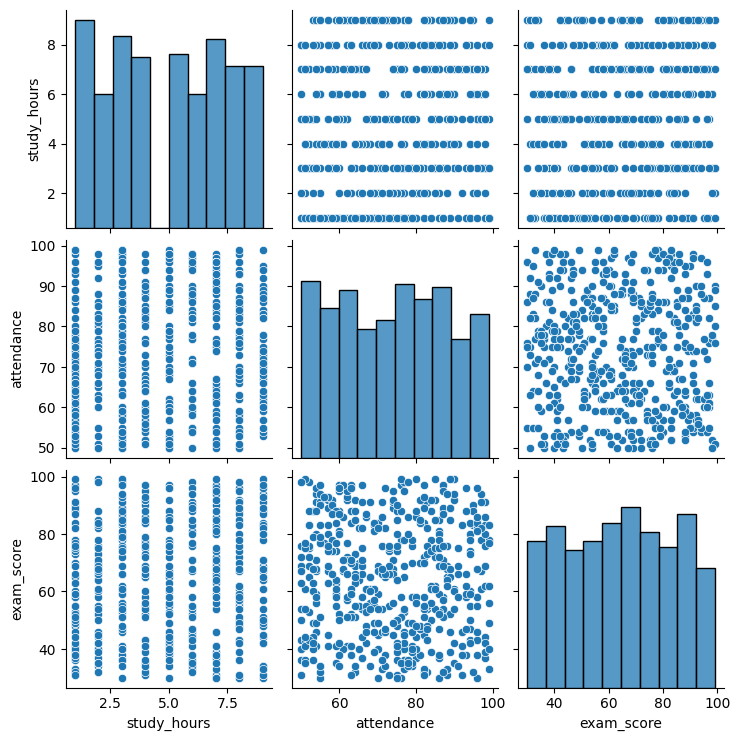

In [29]:
# Pairplot
sns.pairplot(df[["study_hours","attendance","exam_score"]])
plt.show()

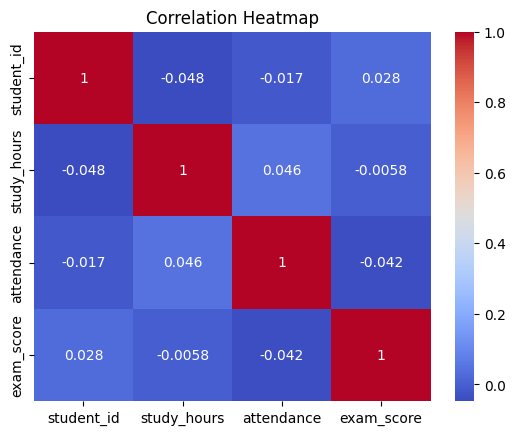

In [35]:
# Heatmap
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

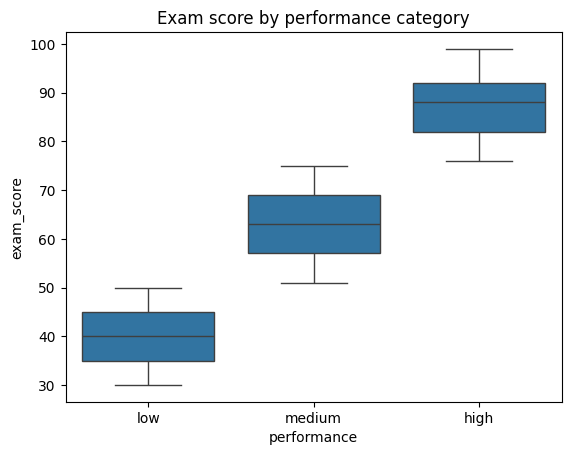

In [36]:
# Boxplot
sns.boxplot(x="performance",y="exam_score",data=df)
plt.title("Exam score by performance category")
plt.show()

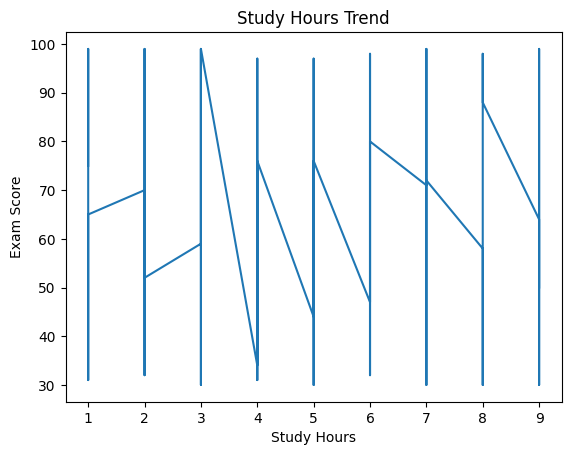

In [38]:
# Line plot (sorted)
df_sorted=df.sort_values("study_hours")
plt.plot(df_sorted["study_hours"],df_sorted["exam_score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours Trend")
plt.show()